# Statistical values distribution - Cortical Volume

In [8]:
from IPython.display import display, Image

STATIC_RENDERING = True


# This is a static rendering of the notebook.
def show_figure(fig):
    if STATIC_RENDERING:
        img = fig.to_image(format="png")
        display(Image(img))
    else:
        fig.show()


In [9]:
# Comment out the following line to run the notebook in CPU mode
%load_ext cudf.pandas
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go
import numpy as np
import plotly

# Suppress warnings
import warnings

warnings.filterwarnings("ignore")

# Define cortical regions - these should represent cortical volumes
cortical_regions = [
    "bankssts",
    "caudalanteriorcingulate",
    "caudalmiddlefrontal",
    "cuneus",
    "entorhinal",
    "fusiform",
    "inferiorparietal",
    "inferiortemporal",
    "isthmuscingulate",
    "lateraloccipital",
    "lateralorbitofrontal",
    "lingual",
    "medialorbitofrontal",
    "middletemporal",
    "parahippocampal",
    "paracentral",
    "parsopercularis",
    "parsorbitalis",
    "parstriangularis",
    "pericalcarine",
    "postcentral",
    "posteriorcingulate",
    "precentral",
    "precuneus",
    "rostralanteriorcingulate",
    "rostralmiddlefrontal",
    "superiorfrontal",
    "superiorparietal",
    "superiortemporal",
    "supramarginal",
    "frontalpole",
    "temporalpole",
    "transversetemporal",
    "insula",
]


# Define hemisphere-specific symbols
def get_hemisphere_symbol(hemi):
    """Return symbol based on hemisphere"""
    if hemi == "Left":
        return "triangle-left"
    elif hemi == "Right":
        return "triangle-right"
    else:
        return "diamond"


def get_hemisphere_color(hemi):
    """Return color based on hemisphere"""
    return plotly.colors.qualitative.Set1[0]  # Red for other
    if hemi == "Left":
        return plotly.colors.qualitative.Set1[1]  # Orange for left hemisphere
    elif hemi == "Right":
        return plotly.colors.qualitative.Set1[2]  # Green for right hemisphere
    else:
        return plotly.colors.qualitative.Set1[0]  # Red for other


red = plotly.colors.qualitative.Set1[0]
ieee_marker = dict(color=red, symbol="diamond", size=10)
violin_width = 0.85
violin_jitter = 0.85


The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


In [10]:
def get_pcorr_baseline_cortical():
    """Load baseline partial correlation data for cortical volume"""
    baseline_cortical_volume = pd.read_parquet(
        "partial_correlation/partial_correlation_baseline_volume.parquet"
    )
    baseline_cortical_volume["significant"] = baseline_cortical_volume["p-val"] < 0.05
    baseline_cortical_volume_avg = (
        baseline_cortical_volume.groupby(["hemisphere", "region"])
        .agg({"r": "mean", "significant": "mean"})
        .reset_index()
    )

    ieee_data = pd.read_csv(
        "partial_correlation_ieee/partial_correlation_baseline_volume.csv"
    )

    ieee_data.sort_values(by=["region"], inplace=True)
    ieee_data["fs_version"] = "IEEE"

    # Filter regions present in cortical data
    baseline_cortical_volume = baseline_cortical_volume[
        baseline_cortical_volume["region"].isin(cortical_regions)
    ]
    baseline_cortical_volume_avg = baseline_cortical_volume_avg[
        baseline_cortical_volume_avg["region"].isin(cortical_regions)
    ]
    ieee_data = ieee_data[ieee_data["region"].isin(cortical_regions)]
    # Create position mapping
    region_to_position = {region: i for i, region in enumerate(cortical_regions)}

    # Add position and hemisphere info
    for df in [baseline_cortical_volume, baseline_cortical_volume_avg, ieee_data]:
        df["position"] = df["region"].map(region_to_position)
        df["hemisphere"] = df["hemisphere"].apply(
            lambda x: "Left" if x.startswith("lh") else "Right"
        )
        df["symbol"] = df["region"].apply(get_hemisphere_symbol)
        df["hemisphere_color"] = df["region"].apply(get_hemisphere_color)

    # Sort by position
    baseline_cortical_volume.sort_values(by="position", inplace=True)
    baseline_cortical_volume_avg.sort_values(by="position", inplace=True)
    ieee_data.sort_values(by="position", inplace=True)

    return {
        "baseline_cortical_volume": baseline_cortical_volume,
        "baseline_cortical_volume_avg": baseline_cortical_volume_avg,
        "ieee_data": ieee_data,
    }


def add_pcorr_baseline_cortical_trace(fig, data, hemi=None):
    """Add baseline partial correlation traces for cortical volume"""
    row, col = 1, 1

    baseline_cortical_volume = data["baseline_cortical_volume"]
    ieee_data = data["ieee_data"]

    baseline_cortical_volume = baseline_cortical_volume[
        baseline_cortical_volume["hemisphere"] == hemi
    ]
    blue = px.colors.qualitative.Plotly[4]

    # Add violin plot
    violin = go.Violin(
        x=baseline_cortical_volume["region"],
        y=baseline_cortical_volume["r"],
        yaxis="y2",
        box_visible=False,
        line_color="DarkSlateGrey",
        meanline_visible=True,
        fillcolor="gray",
        opacity=0.6,
        width=violin_width,
        jitter=violin_jitter,
        showlegend=False,
        name="r coefficient",
        spanmode="hard",
        points="all",
        pointpos=0,
        marker=dict(color="orange", opacity=1),
        customdata=baseline_cortical_volume["region"],
        hovertemplate="Region: %{customdata}<br>r: %{y:.3f}<extra></extra>",
    )

    # Add IEEE data with hemisphere-specific symbols
    hemispheres = [hemi] if hemi else ["Left", "Right"]
    for hemisphere in hemispheres:
        ieee_hemisphere = ieee_data[ieee_data["hemisphere"] == hemisphere]
        if not ieee_hemisphere.empty:
            symbol = get_hemisphere_symbol(hemisphere)
            color = get_hemisphere_color(hemisphere)
            ieee_scatter = go.Scatter(
                x=ieee_hemisphere["region"],
                y=ieee_hemisphere["r"],
                mode="markers",
                yaxis="y2",
                marker=dict(color=color, symbol=symbol, size=10),
                showlegend=True,
                name=f"IEEE {hemisphere}",
                customdata=ieee_hemisphere["region"],
                hovertemplate="Region: %{customdata}<br>r: %{y:.3f}<extra></extra>",
            )
            fig.add_trace(ieee_scatter, row=row, col=col)

    fig.add_trace(violin, row=row, col=col)


In [11]:
def get_pcorr_long_cortical():
    """Load longitudinal partial correlation data for cortical volume"""
    longitudinal_cortical_volume = pd.read_parquet(
        "partial_correlation/partial_correlation_longitudinal_volume.parquet"
    )

    longitudinal_cortical_volume["significant"] = (
        longitudinal_cortical_volume["p-val"] < 0.05
    )
    longitudinal_cortical_volume_avg = (
        longitudinal_cortical_volume.groupby(["hemisphere", "region"])
        .agg({"r": "mean", "significant": "mean"})
        .reset_index()
    )

    ieee_data = pd.read_csv(
        "partial_correlation_ieee/partial_correlation_longitudinal_volume.csv"
    )

    ieee_data.sort_values(by=["region"], inplace=True)
    ieee_data["fs_version"] = "IEEE"

    # Filter regions
    longitudinal_cortical_volume = longitudinal_cortical_volume[
        longitudinal_cortical_volume["region"].isin(cortical_regions)
    ]
    longitudinal_cortical_volume_avg = longitudinal_cortical_volume_avg[
        longitudinal_cortical_volume_avg["region"].isin(cortical_regions)
    ]
    ieee_data = ieee_data[ieee_data["region"].isin(cortical_regions)]

    # Create position mapping
    region_to_position = {region: i for i, region in enumerate(cortical_regions)}

    # Add position and hemisphere info
    for df in [
        longitudinal_cortical_volume,
        longitudinal_cortical_volume_avg,
        ieee_data,
    ]:
        df["position"] = df["region"].map(region_to_position)
        df["hemisphere"] = df["hemisphere"].apply(
            lambda x: "Left" if x.startswith("lh") else "Right"
        )
        df["symbol"] = df["region"].apply(get_hemisphere_symbol)
        df["hemisphere_color"] = df["region"].apply(get_hemisphere_color)

    # Sort by position
    longitudinal_cortical_volume.sort_values(by="position", inplace=True)
    longitudinal_cortical_volume_avg.sort_values(by="position", inplace=True)
    ieee_data.sort_values(by="position", inplace=True)

    return {
        "longitudinal_cortical_volume": longitudinal_cortical_volume,
        "longitudinal_cortical_volume_avg": longitudinal_cortical_volume_avg,
        "ieee_data": ieee_data,
    }


def add_pcorr_longitudinal_cortical_trace(fig, data, hemi=None):
    """Add longitudinal partial correlation traces for cortical volume"""
    row, col = 1, 2

    longitudinal_cortical_volume = data["longitudinal_cortical_volume"]
    ieee_data = data["ieee_data"]

    longitudinal_cortical_volume = longitudinal_cortical_volume[
        longitudinal_cortical_volume["hemisphere"] == hemi
    ]

    violin = go.Violin(
        x=longitudinal_cortical_volume["region"],
        y=longitudinal_cortical_volume["r"],
        yaxis="y2",
        box_visible=False,
        line_color="DarkSlateGrey",
        meanline_visible=True,
        fillcolor="gray",
        opacity=0.6,
        width=violin_width,
        jitter=violin_jitter,
        showlegend=False,
        spanmode="hard",
        name="r coefficient",
        points="all",
        marker=dict(color="orange", opacity=1),
        pointpos=0,
        customdata=longitudinal_cortical_volume["region"],
        hovertemplate="Region: %{customdata}<br>r: %{y:.3f}<extra></extra>",
    )

    # Add IEEE data with hemisphere-specific symbols
    hemispheres = [hemi] if hemi else ["Left", "Right"]
    for hemisphere in hemispheres:
        ieee_hemisphere = ieee_data[ieee_data["hemisphere"] == hemisphere]
        if not ieee_hemisphere.empty:
            symbol = get_hemisphere_symbol(hemisphere)
            color = get_hemisphere_color(hemisphere)
            ieee_scatter = go.Scatter(
                x=ieee_hemisphere["region"],
                y=ieee_hemisphere["r"],
                mode="markers",
                yaxis="y2",
                marker=dict(color=color, symbol=symbol, size=10),
                showlegend=False,
                name=f"IEEE {hemisphere}",
                customdata=ieee_hemisphere["region"],
                hovertemplate="Region: %{customdata}<br>r: %{y:.3f}<extra></extra>",
            )
            fig.add_trace(ieee_scatter, row=row, col=col)

    fig.add_trace(violin, row=row, col=col)


In [12]:
def get_ancova_baseline_cortical():
    """Load baseline ANCOVA data for cortical volume"""
    baseline_cortical_volume = pd.read_parquet("ancova/ancova_baseline_volume.parquet")
    baseline_cortical_volume["significant"] = baseline_cortical_volume["p-unc"] < 0.05
    baseline_cortical_volume_avg = (
        baseline_cortical_volume.groupby(["hemisphere", "region"])
        .agg({"F": "mean", "significant": "mean"})
        .reset_index()
    )

    ieee_data = pd.read_csv("ancova_ieee/ancova_baseline_volume.csv")

    ieee_data.sort_values(by=["region"], inplace=True)
    ieee_data["fs_version"] = "IEEE"

    # Filter regions
    baseline_cortical_volume = baseline_cortical_volume[
        baseline_cortical_volume["region"].isin(cortical_regions)
    ]
    baseline_cortical_volume_avg = baseline_cortical_volume_avg[
        baseline_cortical_volume_avg["region"].isin(cortical_regions)
    ]
    ieee_data = ieee_data[ieee_data["region"].isin(cortical_regions)]

    # Create position mapping
    region_to_position = {region: i for i, region in enumerate(cortical_regions)}

    # Add position and hemisphere info
    for df in [baseline_cortical_volume, baseline_cortical_volume_avg, ieee_data]:
        df["position"] = df["region"].map(region_to_position)
        df["hemisphere"] = df["hemisphere"].apply(
            lambda x: "Left" if x.startswith("lh") else "Right"
        )
        df["symbol"] = df["region"].apply(get_hemisphere_symbol)
        df["hemisphere_color"] = df["region"].apply(get_hemisphere_color)

    # Sort by position
    baseline_cortical_volume.sort_values(by="position", inplace=True)
    baseline_cortical_volume_avg.sort_values(by="position", inplace=True)
    ieee_data.sort_values(by="position", inplace=True)

    return {
        "baseline_cortical_volume": baseline_cortical_volume,
        "baseline_cortical_volume_avg": baseline_cortical_volume_avg,
        "ieee_data": ieee_data,
    }


def add_ancova_baseline_cortical_trace(fig, data, hemi=None):
    """Add baseline ANCOVA traces for cortical volume"""
    row, col = 2, 1

    baseline_cortical_volume = data["baseline_cortical_volume"]
    ieee_data = data["ieee_data"]

    baseline_cortical_volume = baseline_cortical_volume[
        baseline_cortical_volume["hemisphere"] == hemi
    ]

    violin = go.Violin(
        x=baseline_cortical_volume["region"],
        y=baseline_cortical_volume["F"],
        yaxis="y2",
        box_visible=False,
        line_color="DarkSlateGrey",
        meanline_visible=True,
        fillcolor="gray",
        opacity=0.6,
        width=violin_width,
        jitter=violin_jitter,
        showlegend=False,
        marker=dict(color="orange", opacity=1),
        pointpos=0,
        name="F-value",
        spanmode="hard",
        points="all",
        customdata=baseline_cortical_volume["region"],
        hovertemplate="Region: %{customdata}<br>F: %{y:.3f}<extra></extra>",
    )

    # Add IEEE data with hemisphere-specific symbols
    hemispheres = [hemi] if hemi else ["Left", "Right"]
    for hemisphere in hemispheres:
        ieee_hemisphere = ieee_data[ieee_data["hemisphere"] == hemisphere]
        if not ieee_hemisphere.empty:
            symbol = get_hemisphere_symbol(hemisphere)
            color = get_hemisphere_color(hemisphere)
            ieee_scatter = go.Scatter(
                x=ieee_hemisphere["region"],
                y=ieee_hemisphere["F"],
                mode="markers",
                yaxis="y2",
                marker=dict(color=color, symbol=symbol, size=10),
                showlegend=False,
                name=f"IEEE {hemisphere}",
                customdata=ieee_hemisphere["region"],
                hovertemplate="Region: %{customdata}<br>F: %{y:.3f}<extra></extra>",
            )
            fig.add_trace(ieee_scatter, row=row, col=col)

    fig.add_trace(violin, row=row, col=col)


In [13]:
def get_ancova_long_cortical():
    """Load longitudinal ANCOVA data for cortical volume"""
    longitudinal_cortical_volume = pd.read_parquet(
        "ancova/ancova_longitudinal_volume.parquet"
    )
    longitudinal_cortical_volume["significant"] = (
        longitudinal_cortical_volume["p-unc"] < 0.05
    )
    longitudinal_cortical_volume_avg = (
        longitudinal_cortical_volume.groupby(["hemisphere", "region"])
        .agg({"F": "mean", "significant": "mean"})
        .reset_index()
    )

    ieee_data = pd.read_csv("ancova_ieee/ancova_longitudinal_volume.csv")

    ieee_data.sort_values(by=["region"], inplace=True)
    ieee_data["fs_version"] = "IEEE"

    # Filter regions
    longitudinal_cortical_volume = longitudinal_cortical_volume[
        longitudinal_cortical_volume["region"].isin(cortical_regions)
    ]
    longitudinal_cortical_volume_avg = longitudinal_cortical_volume_avg[
        longitudinal_cortical_volume_avg["region"].isin(cortical_regions)
    ]
    ieee_data = ieee_data[ieee_data["region"].isin(cortical_regions)]

    # Create position mapping
    region_to_position = {region: i for i, region in enumerate(cortical_regions)}

    # Add position and hemisphere info
    for df in [
        longitudinal_cortical_volume,
        longitudinal_cortical_volume_avg,
        ieee_data,
    ]:
        df["position"] = df["region"].map(region_to_position)
        df["hemisphere"] = df["hemisphere"].apply(
            lambda x: "Left" if x.startswith("lh") else "Right"
        )
        df["symbol"] = df["region"].apply(get_hemisphere_symbol)
        df["hemisphere_color"] = df["region"].apply(get_hemisphere_color)

    # Sort by position
    longitudinal_cortical_volume.sort_values(by="position", inplace=True)
    longitudinal_cortical_volume_avg.sort_values(by="position", inplace=True)
    ieee_data.sort_values(by="position", inplace=True)

    return {
        "longitudinal_cortical_volume": longitudinal_cortical_volume,
        "longitudinal_cortical_volume_avg": longitudinal_cortical_volume_avg,
        "ieee_data": ieee_data,
    }


def add_ancova_longitudinal_cortical_trace(fig, data, hemi=None):
    """Add longitudinal ANCOVA traces for cortical volume"""
    row, col = 2, 2

    longitudinal_cortical_volume = data["longitudinal_cortical_volume"]
    ieee_data = data["ieee_data"]

    longitudinal_cortical_volume = longitudinal_cortical_volume[
        longitudinal_cortical_volume["hemisphere"] == hemi
    ]

    violin = go.Violin(
        x=longitudinal_cortical_volume["region"],
        y=longitudinal_cortical_volume["F"],
        yaxis="y2",
        box_visible=False,
        line_color="DarkSlateGrey",
        fillcolor="gray",
        meanline_visible=False,
        pointpos=0,
        marker=dict(
            color="orange",
            opacity=1,
        ),
        width=violin_width,
        jitter=violin_jitter,
        opacity=0.6,
        showlegend=False,
        name="F-value",
        points="all",
        spanmode="hard",
        customdata=longitudinal_cortical_volume["region"],
        hovertemplate="Region: %{customdata}<br>F: %{y:.3f}<extra></extra>",
    )

    # Add IEEE data with hemisphere-specific symbols
    hemispheres = [hemi] if hemi else ["Left", "Right"]
    for hemisphere in hemispheres:
        ieee_hemisphere = ieee_data[ieee_data["hemisphere"] == hemisphere]
        if not ieee_hemisphere.empty:
            symbol = get_hemisphere_symbol(hemisphere)
            color = get_hemisphere_color(hemisphere)
            ieee_scatter = go.Scatter(
                x=ieee_hemisphere["region"],
                y=ieee_hemisphere["F"],
                mode="markers",
                yaxis="y2",
                marker=dict(color=color, symbol=symbol, size=10),
                showlegend=False,
                name=f"IEEE {hemisphere}",
                customdata=ieee_hemisphere["region"],
                hovertemplate="Region: %{customdata}<br>F: %{y:.3f}<extra></extra>",
            )
            fig.add_trace(ieee_scatter, row=row, col=col)

    fig.add_trace(violin, row=row, col=col)


## Consistency of Statistically Significant Regions

This analysis quantifies the consistency of statistically significant findings across different brain regions. For each region, we compute the proportion of statistical tests that yield significant results relative to the total number of tests performed. 

'Number of cortical regions: 34'

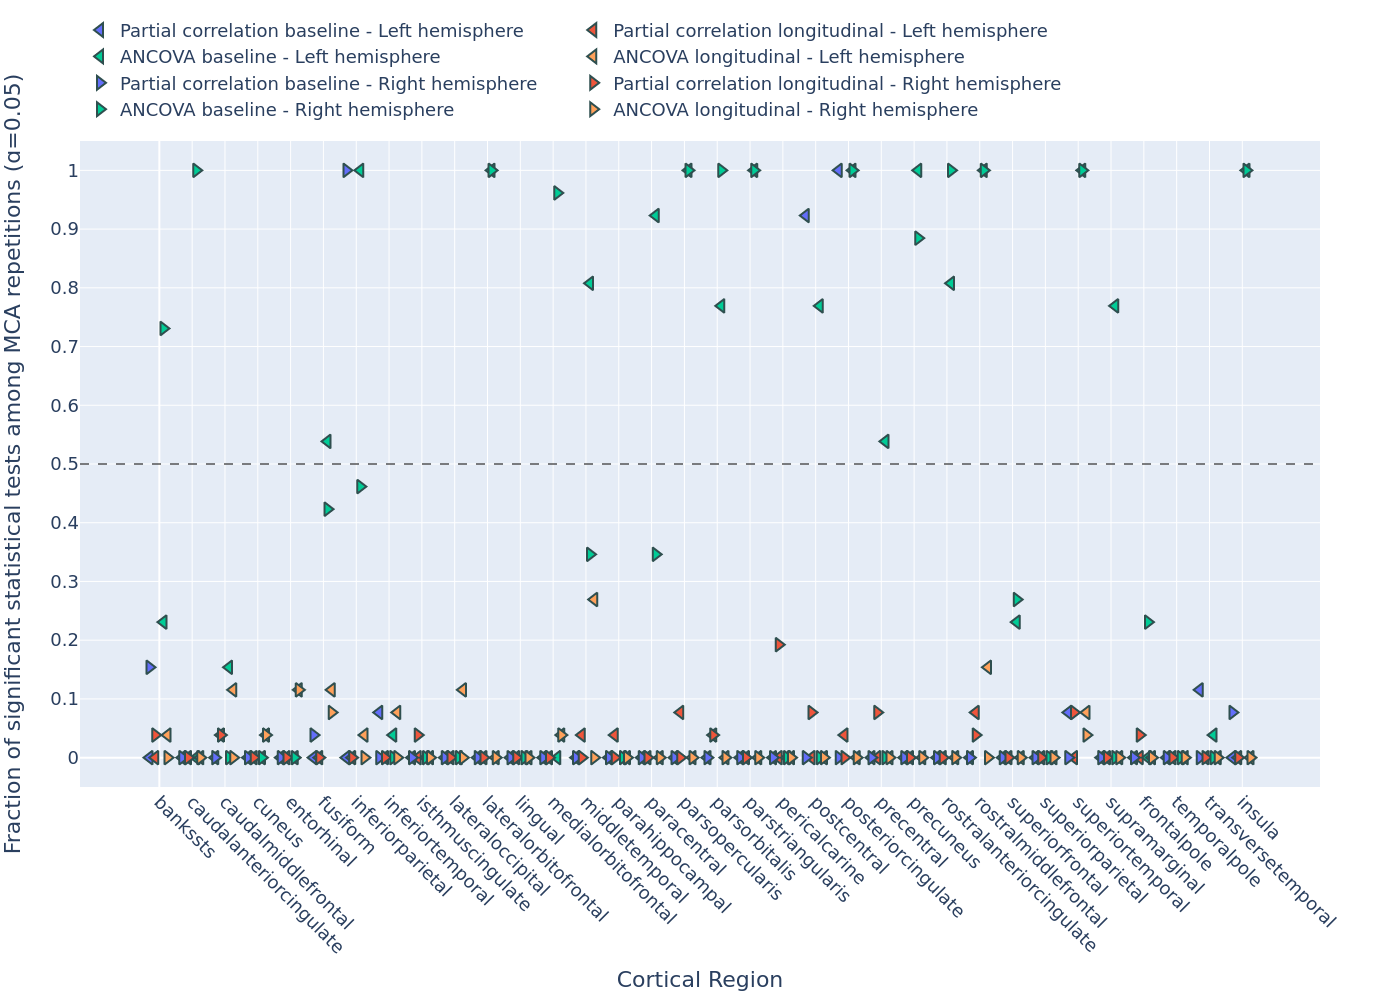

In [14]:
# Significance correlation plot for cortical volume
pcorr_baseline_cortical_avg = get_pcorr_baseline_cortical()[
    "baseline_cortical_volume_avg"
]
pcorr_longitudinal_cortical_avg = get_pcorr_long_cortical()[
    "longitudinal_cortical_volume_avg"
]
ancova_baseline_cortical_avg = get_ancova_baseline_cortical()[
    "baseline_cortical_volume_avg"
]
ancova_longitudinal_cortical_avg = get_ancova_long_cortical()[
    "longitudinal_cortical_volume_avg"
]
display(f"Number of cortical regions: {len(cortical_regions)}")
fig = go.Figure()

colormap = px.colors.qualitative.Plotly
marker_size = 12
marker_line = dict(width=2, color="DarkSlateGrey")


def get_jittered_positions(length, jitter_amount):
    """Generate jittered x-axis positions"""
    return [x + jitter_amount for x in range(length)]


# Create hemisphere-specific traces
for hemisphere, symbol in [
    ("Left", "triangle-left"),
    ("Right", "triangle-right"),
]:
    # Partial correlation baseline
    data_subset = pcorr_baseline_cortical_avg[
        pcorr_baseline_cortical_avg["hemisphere"] == hemisphere
    ]
    if not data_subset.empty:
        pcorr_base = go.Scatter(
            x=get_jittered_positions(len(data_subset), -0.3),
            y=data_subset["significant"],
            mode="markers",
            marker=dict(
                color=colormap[0], size=marker_size, symbol=symbol, line=marker_line
            ),
            name=f"Partial correlation baseline - {hemisphere} hemisphere",
            text=data_subset["region"],
        )
        fig.add_trace(pcorr_base)
    else:
        raise ValueError(
            f"No data for Partial correlation baseline - {hemisphere} hemisphere"
        )

    # Partial correlation longitudinal
    data_subset = pcorr_longitudinal_cortical_avg[
        pcorr_longitudinal_cortical_avg["hemisphere"] == hemisphere
    ]

    if not data_subset.empty:
        pcorr_long = go.Scatter(
            x=get_jittered_positions(len(data_subset), -0.125),
            y=data_subset["significant"],
            mode="markers",
            marker=dict(
                color=colormap[1], size=marker_size, symbol=symbol, line=marker_line
            ),
            name=f"Partial correlation longitudinal - {hemisphere} hemisphere",
        )
        fig.add_trace(pcorr_long)
    else:
        raise ValueError(
            f"No data for Partial correlation longitudinal - {hemisphere} hemisphere"
        )

    # ANCOVA baseline
    data_subset = ancova_baseline_cortical_avg[
        ancova_baseline_cortical_avg["hemisphere"] == hemisphere
    ]
    if not data_subset.empty:
        ancova_base = go.Scatter(
            x=get_jittered_positions(len(data_subset), 0.125),
            y=data_subset["significant"],
            mode="markers",
            marker=dict(
                color=colormap[2], size=marker_size, symbol=symbol, line=marker_line
            ),
            name=f"ANCOVA baseline - {hemisphere} hemisphere",
        )
        fig.add_trace(ancova_base)
    else:
        raise ValueError(f"No data for ANCOVA baseline - {hemisphere} hemisphere")

    # ANCOVA longitudinal
    data_subset = ancova_longitudinal_cortical_avg[
        ancova_longitudinal_cortical_avg["hemisphere"] == hemisphere
    ]
    if not data_subset.empty:
        ancova_long = go.Scatter(
            x=get_jittered_positions(len(data_subset), 0.25),
            y=data_subset["significant"],
            mode="markers",
            marker=dict(
                color=colormap[4], size=marker_size, symbol=symbol, line=marker_line
            ),
            name=f"ANCOVA longitudinal - {hemisphere} hemisphere",
        )
        fig.add_trace(ancova_long)
    else:
        raise ValueError(f"No data for ANCOVA longitudinal - {hemisphere} hemisphere")

fig.update_xaxes(
    title="Cortical Region",
    tickmode="array",
    tickvals=list(range(len(cortical_regions))),
    ticktext=cortical_regions,
    tickangle=45,
)
fig.update_yaxes(
    title="Fraction of significant statistical tests among MCA repetitions (ɑ=0.05)",
    range=[-0.05, 1.05],
    dtick=0.1,
)

# Position legend
fig.update_layout(
    legend=dict(
        x=0.0,
        y=1.20,
        xanchor="left",
        yanchor="top",
        orientation="h",
        bgcolor="rgba(255, 255, 255, 0)",
    )
)

# Increase font size
fig.update_layout(font=dict(size=18))

fig.add_hline(y=0.5, line_color="black", line_width=1, line_dash="dash")

fig.update_layout(width=1400, height=1000)

plotly.io.write_image(fig, "cortical_volume_significance_correlation.pdf")
show_figure(fig)


## Distribution of Statistical Values

Distribution of statistical values, specifically the correlation coefficients (r) from partial correlation analyses and the F-values from ANCOVA tests.

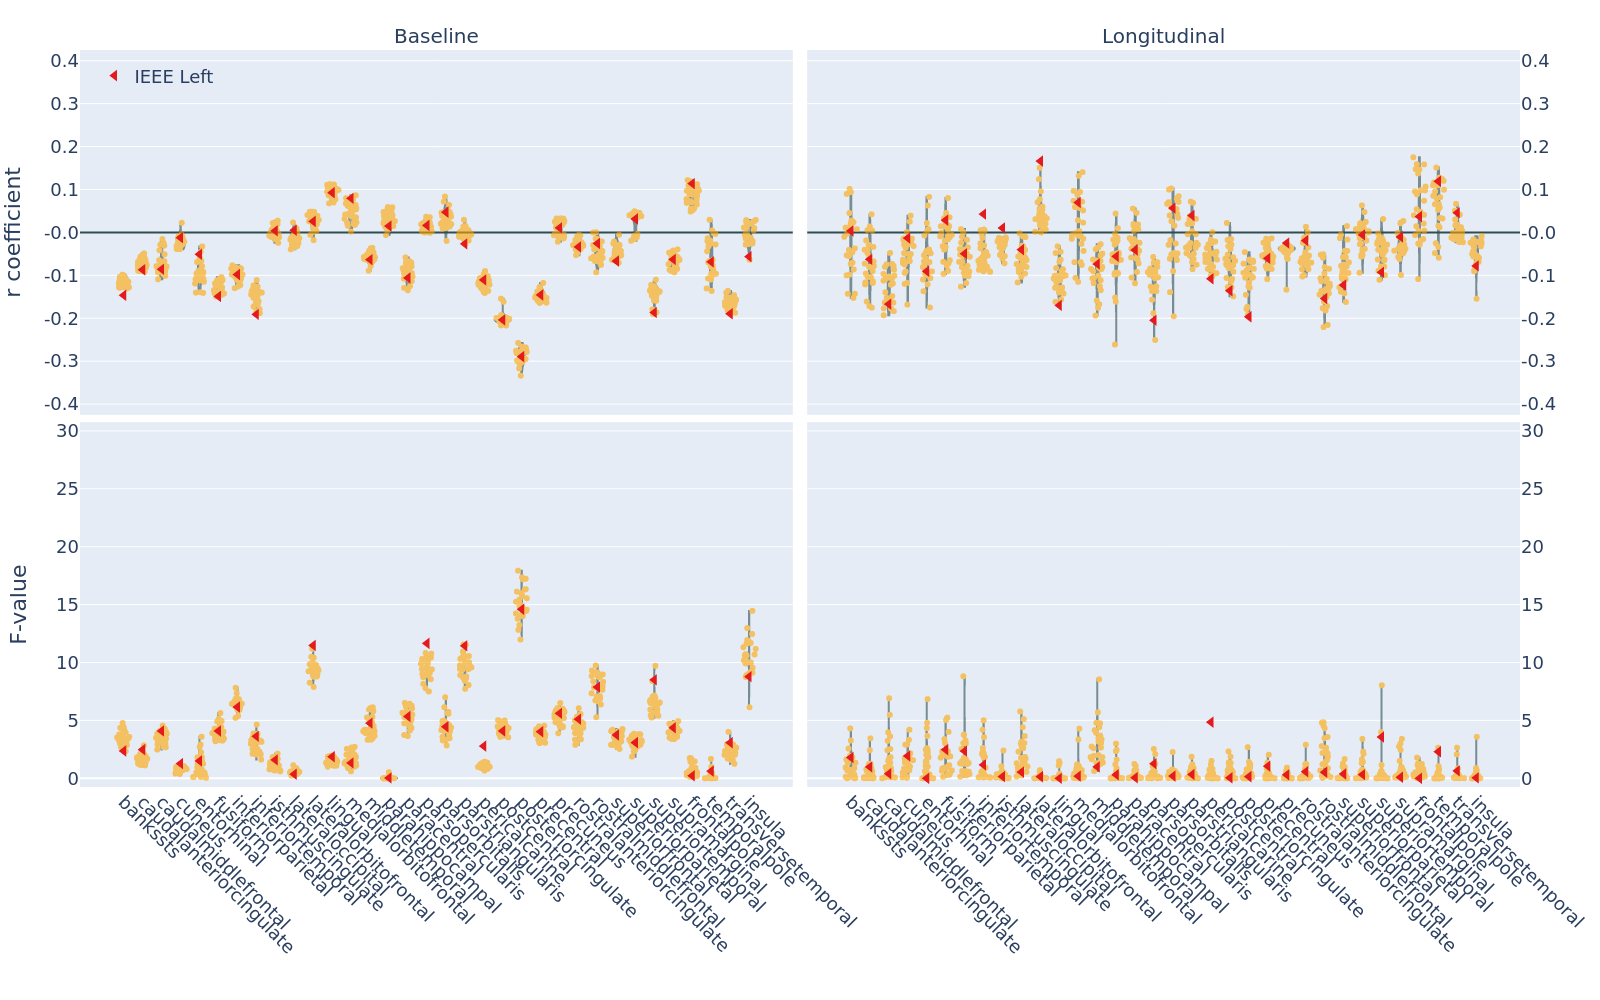

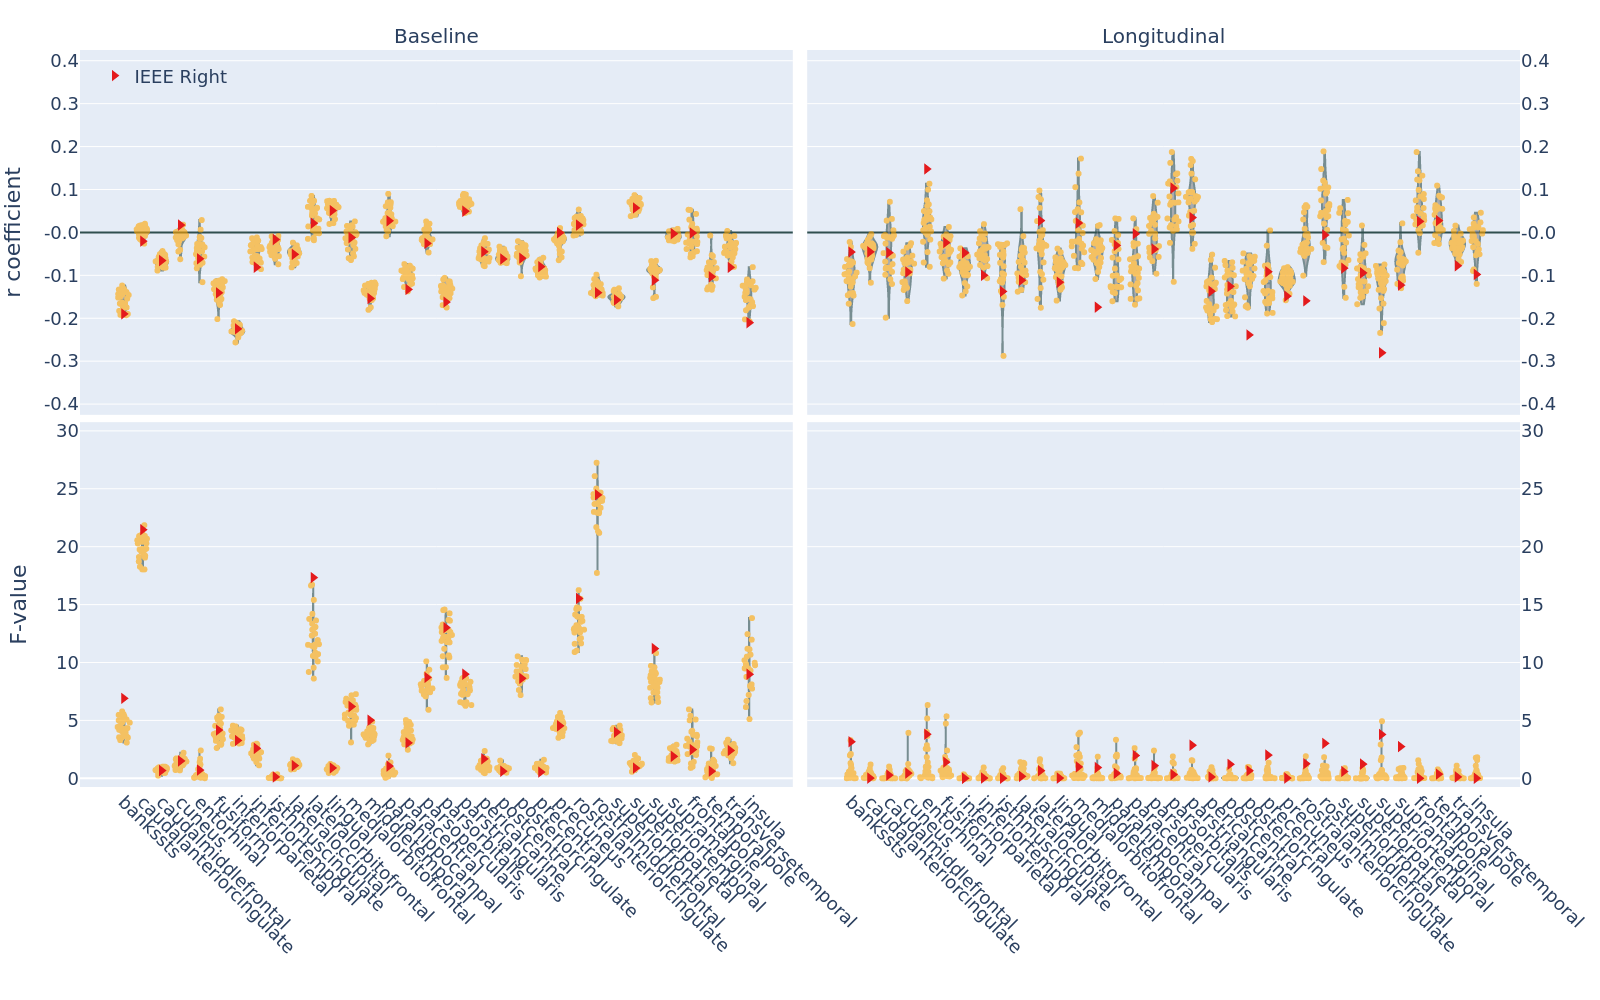

In [15]:
# Main cortical volume coefficient distribution plot
from plotly.subplots import make_subplots

for hemi in ["Left", "Right"]:
    # Create subplots with 2 rows and 2 columns
    fig = make_subplots(
        rows=2,
        cols=2,
        shared_xaxes=True,
        column_titles=["Baseline", "Longitudinal"],
        x_title="Cortical Region",
        vertical_spacing=0.01,
        horizontal_spacing=0.01,
    )

    # Increase font
    fig.update_layout(font=dict(size=18))

    # Add traces to the subplots
    add_pcorr_baseline_cortical_trace(fig, get_pcorr_baseline_cortical(), hemi=hemi)
    add_pcorr_longitudinal_cortical_trace(fig, get_pcorr_long_cortical(), hemi=hemi)
    add_ancova_baseline_cortical_trace(fig, get_ancova_baseline_cortical(), hemi=hemi)
    add_ancova_longitudinal_cortical_trace(fig, get_ancova_long_cortical(), hemi=hemi)

    # Set x-axis ticks and labels - remove hemisphere prefix for readability
    simplified_labels = [
        region.replace("lh_", "").replace("rh_", "") for region in cortical_regions
    ]
    fig.update_xaxes(
        title_text="",
        tickvals=list(range(len(cortical_regions))),
        ticktext=simplified_labels,
        tickangle=45,
    )

    yaxis_r_range = [-0.425, 0.425]
    yaxis_r_tickvals = np.arange(-0.5, 0.6, 0.1)
    yaxis_r_ticktext = [str(round(x, 1)) for x in yaxis_r_tickvals]

    yaxis_f_range = [-0.75, 30.75]
    yaxis_f_tickvals = [0, 10, 20, 30, 40, 50]
    yaxis_f_ticktext = ["0", "10", "20", "30", "40", "50"]

    # Update layout for all axes
    fig.update_layout(
        # Primary y-axes (correlation coefficients)
        yaxis1=dict(
            title="r coefficient",
            range=yaxis_r_range,
            dtick=0.1,
            showgrid=True,
            zeroline=True,
            zerolinewidth=2,
            zerolinecolor="DarkSlateGrey",
            tickvals=yaxis_r_tickvals,
            ticktext=yaxis_r_ticktext,
        ),
        yaxis2=dict(
            dtick=0.1,
            showgrid=True,
            range=yaxis_r_range,
            zeroline=True,
            zerolinewidth=2,
            zerolinecolor="DarkSlateGrey",
            tickvals=yaxis_r_tickvals,
            ticktext=yaxis_r_ticktext,
            side="right",
        ),
        yaxis3=dict(
            title="F-value",
            range=yaxis_f_range,
            showgrid=True,
        ),
        yaxis4=dict(showgrid=True, range=yaxis_f_range, side="right"),
        # Legend settings
        legend=dict(
            x=0.01,
            y=0.99,
            orientation="h",
            yanchor="top",
            xanchor="left",
            bgcolor="rgba(255, 255, 255, 0)",
        ),
        margin=dict(t=50, b=200, r=20),
    )

    # Increase font size
    fig.update_layout(
        font=dict(size=18),
    )

    annotations = fig.layout.annotations
    for i in range(len(annotations)):
        annotations[i].font.size = 20

    for annotation in annotations:
        if annotation.text == "Cortical Region":
            annotation.update(y=-0.25)

    fig.update_layout(height=1000, width=1600)
    plotly.io.write_image(fig, f"cortical_volume_coefficients_distribution-{hemi}.pdf")

    show_figure(fig)
